### David Roca Tauste

---
# Representaciones gráficas de datos. Ejercicios con Matplotlib (y Pandas)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Ejercicio 1
Escribe una función que reciba un dataframe de Pandas con los ingresos y gastos de una empresa por meses durante un año, y devuelva un diagrama de líneas con dos líneas, una para los ingresos y otra para los gastos. El diagrama debe tener una leyenda identificando la línea de los ingresos y la de los gastos, un título con el nombre “Evolución de ingresos y gastos” y el eje y debe empezar en 0. Genera datos aleatorios para probar el funcionamiento.

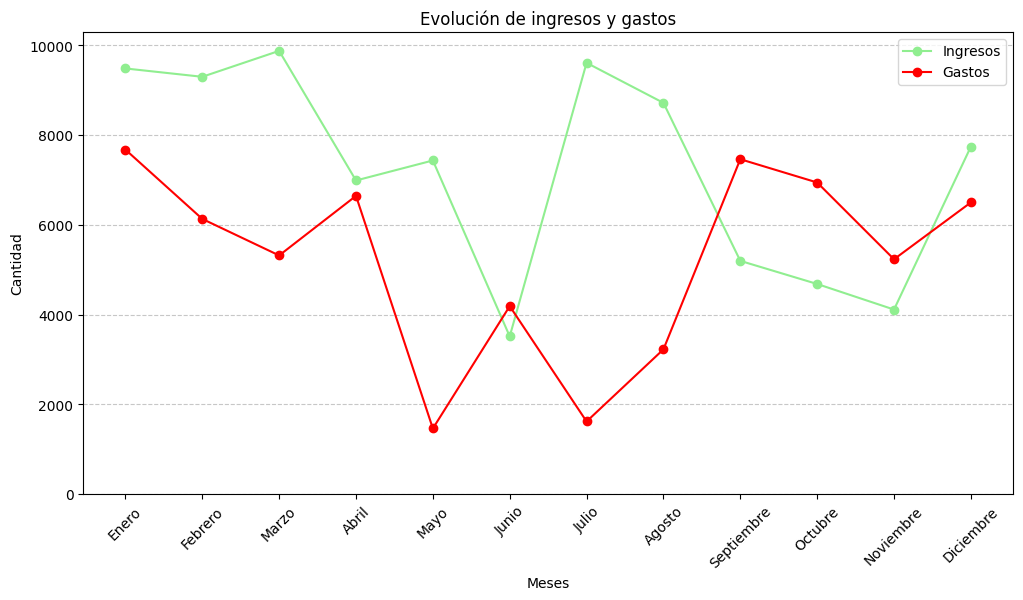

In [ ]:
def diagramaIngresosGastos(df):
    plt.figure(figsize=(12, 6))
    
    plt.plot(df['Mes'], df['Ingresos'], label='Ingresos', marker='o', color='lightgreen')
    plt.plot(df['Mes'], df['Gastos'], label='Gastos', marker='o', color='red')
    
    plt.title("Evolución de ingresos y gastos")
    plt.xlabel("Meses")
    plt.ylabel("Cantidad")
    plt.legend()
    plt.ylim(0)
    # Para que se distingan mejor los datos.
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    
    plt.show()


meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

ingresos = np.random.randint(2000, 10000, size=12)
gastos = np.random.randint(1000, 8000, size=12)

df = pd.DataFrame({'Mes': meses, 'Ingresos': ingresos, 'Gastos': gastos})
diagramaIngresosGastos(df)

---
## Ejercicio 2
Escribe una función que reciba una serie de Pandas con las notas de los alumnos de un módulo cualquiera (generadas aleatoriamente o inventadas) y devuelva un diagrama de caja. El diagrama debe tener el título “Distribución de notas”. Luego debes conseguir pasarle un dataframe con las notas de 4 módulos diferentes y, en la misma zona, mostrar las cajas de la distribución de los 4 módulos.

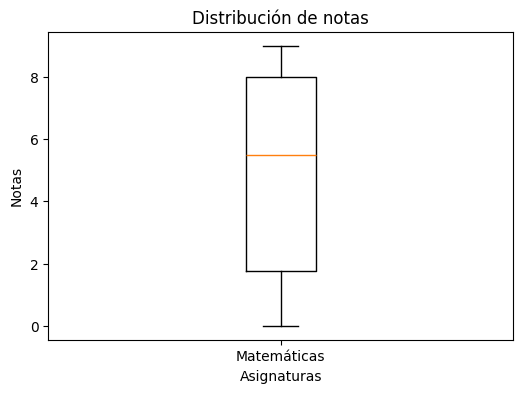

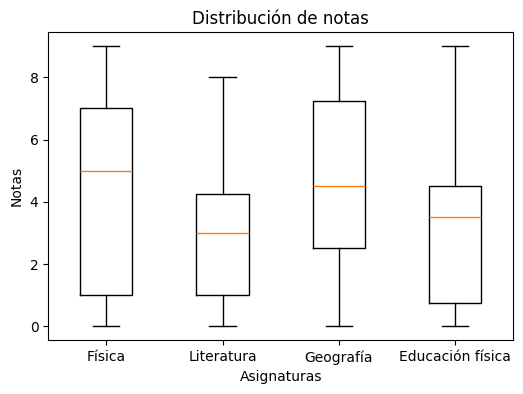

In [31]:
def diagramaNotas(info):
    plt.figure(figsize=(6, 4))
    
    notas = [nota['notas'] for nota in info]
    etiquetas = [asignatura['modulo'] for asignatura in info]

    plt.boxplot(notas, tick_labels=etiquetas)

    plt.title("Distribución de notas")
    plt.xlabel("Asignaturas")
    plt.ylabel("Notas")

    plt.show()


modulos = ["Matemáticas", "Física", "Literatura", "Geografía", "Educación física"]
notas = [np.random.randint(0, 10, size=20) for _ in range(5)]

datos = [{'modulo': modulos[i], 'notas': notas[i]} for i in range(len(modulos))]

diagramaNotas([datos[0]])
diagramaNotas(datos[1:])

---
## Ejercicio 3
Dispones de datos sobre las edades de pacientes en un estudio de predicción de enfermedades cardíacas, para ello debes generar un conjunto de datos simulado con 500 edades entre 20 y 80 años, siguiendo una distribución normal. Crea un histograma para visualizar la distribución de las edades e identifica posibles sesgos, si los hay. Ponle un formato visualmente más agradable que el estándar.

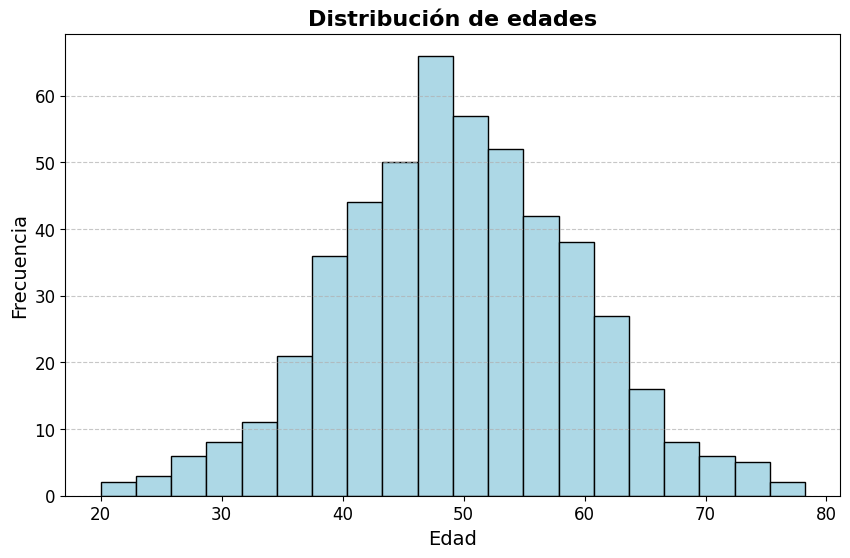

In [ ]:
media = 50
desviacion_estandar = 10

edades = np.random.normal(loc=media, scale=desviacion_estandar, size=500)
edades = np.clip(edades, 20, 80)

plt.figure(figsize=(10, 6))
plt.hist(edades, bins=20, color='lightblue', edgecolor='black')

# He personalizado el histograma para que quede más agradable visualmente como dice el enunciado.
plt.title('Distribución de edades', fontsize=16, fontweight='bold')
plt.xlabel('Edad', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

---
## Ejercicio 4
El fichero titanic.csv contiene información sobre los pasajeros del Titanic. Vamos a explorar su información mediante representaciones gráficas, para ello, crea un dataframe con Pandas a partir del CSV, luego, debes generar las siguientes representaciones independientes (pon título a todas, así como a los ejes X e Y, intenta cuidar el aspecto de la visualización):
- a) Diagrama de sectores con los fallecidos y supervivientes.
- b) Histograma con las edades.
- c) Diagrama de barras con el número de personas en cada clase.
- d) Diagrama de barras con el número de personas fallecidas y supervivientes en cada clase.
- e) Diagrama de barras con el número de personas fallecidas y supervivientes acumuladas en cada clase.

In [33]:
ruta = "titanic.csv"
df = pd.read_csv(ruta)

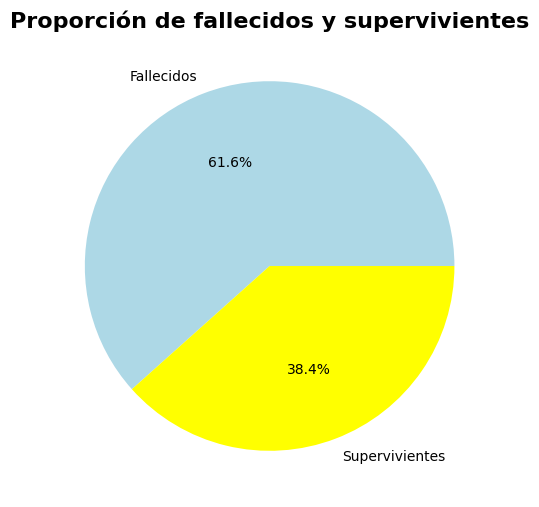

In [ ]:
# a) Diagrama de sectores con los fallecidos y supervivientes.
supervivientes = df["Survived"].value_counts()
posibilidades = ["Fallecidos", "Supervivientes"]

plt.figure(figsize=(8, 6))
plt.pie(
    supervivientes,
    labels=posibilidades,
    colors=["lightblue", "yellow"],
    autopct="%1.1f%%",
)
plt.title("Proporción de fallecidos y supervivientes", fontsize=16, fontweight="bold")
plt.show()

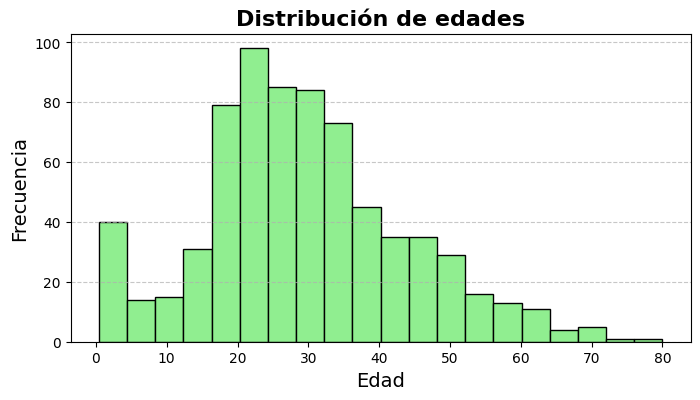

In [35]:
# b) Histograma con las edades.
plt.figure(figsize=(8, 4))
plt.hist(df["Age"], bins=20,  color="lightgreen", edgecolor="black")
plt.title("Distribución de edades", fontsize=16, fontweight="bold")
plt.xlabel("Edad", fontsize=14)
plt.ylabel("Frecuencia", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

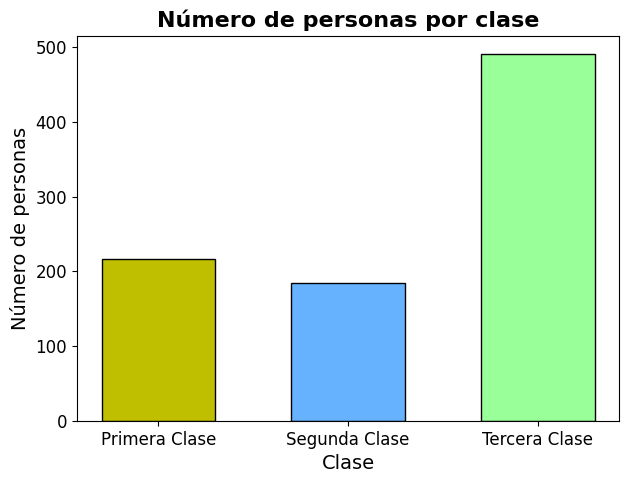

In [ ]:
# c) Diagrama de barras con el número de personas en cada clase.
cantidad_personas_clase = df["Pclass"].value_counts().sort_index()
tipos_clase = ["Primera Clase", "Segunda Clase", "Tercera Clase"]

plt.figure(figsize=(7, 5))
plt.bar(cantidad_personas_clase.index, cantidad_personas_clase.values, color=['y', '#66B2FF', '#99FF99'], edgecolor='black', width=0.6)
plt.title("Número de personas por clase", fontsize=16, fontweight="bold")
plt.xlabel("Clase", fontsize=14)
plt.ylabel("Número de personas", fontsize=14)
plt.xticks(ticks=cantidad_personas_clase.index, labels=tipos_clase, fontsize=12)  # Le pongo el -1 porque si no se sale.
plt.yticks(fontsize=12)
plt.show()

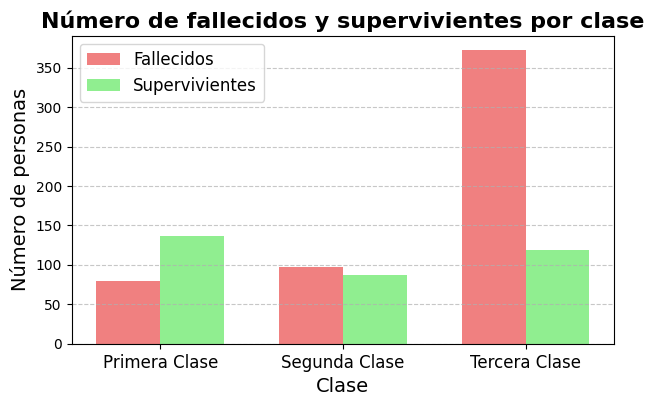

In [37]:
# d) Diagrama de barras con el número de personas fallecidas y supervivientes en cada clase.
supervivientes_clase = df.groupby(["Pclass", "Survived"]).size().unstack()   # Utilizo unstack porque si no aparecen las columnas separadas.
supervivientes_clase.columns = ["Fallecidos", "Supervivientes"]

fallecidos = supervivientes_clase['Fallecidos']
supervivientes = supervivientes_clase['Supervivientes']

x = np.arange(len(tipos_clase))
anchura = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - anchura/2, fallecidos, anchura, label='Fallecidos', color='lightcoral')
plt.bar(x + anchura/2, supervivientes, anchura, label='Supervivientes', color='lightgreen')

# Otra manera
# supervivientes_clase.plot(kind="bar", stacked=False, color=["r", "g"], width=0.7)

plt.title(
    "Número de fallecidos y supervivientes por clase", fontsize=16, fontweight="bold"
)
plt.xlabel("Clase", fontsize=14)
plt.ylabel("Número de personas", fontsize=14)
plt.xticks(ticks=range(3), labels=tipos_clase, rotation=0, fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

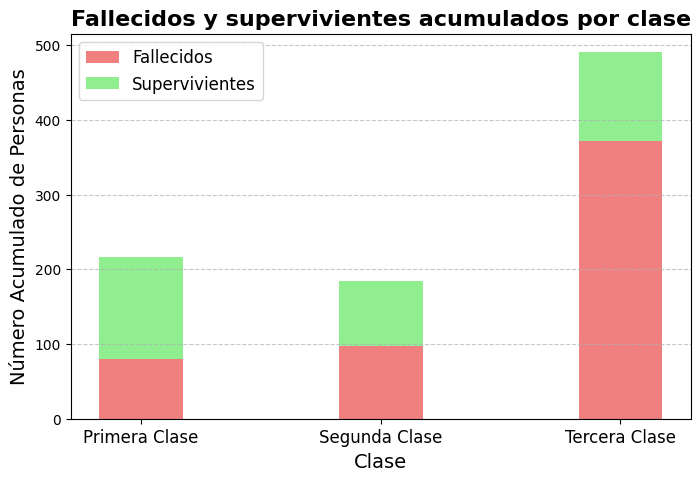

In [38]:
# e) Diagrama de barras con el número de personas fallecidas y supervivientes acumuladas en cada clase.
fallecidos = supervivientes_clase['Fallecidos']
supervivientes = supervivientes_clase['Supervivientes']

x = np.arange(len(tipos_clase))
anchura = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x, fallecidos, anchura, label='Fallecidos', color='lightcoral')
plt.bar(x, supervivientes, anchura, label='Supervivientes', color='lightgreen', bottom=fallecidos)

plt.title(
    "Fallecidos y supervivientes acumulados por clase", fontsize=16, fontweight="bold"
)
plt.xlabel("Clase", fontsize=14)
plt.ylabel("Número Acumulado de Personas", fontsize=14)
plt.xticks(ticks=range(3), labels=tipos_clase, fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

---
## Ejercicio 5
Durante el entrenamiento de una red neuronal, se registró la pérdida (loss) en cada una de las 50 épocas usadas. Simula estos valores usando una función exponencial decreciente. Representa la evolución de la pérdida en un gráfico de líneas y destaca la tendencia general. Se adjunta modelo de referencia de la exponencial decreciente, donde x es la época:
𝑦(𝑥)=𝑒−0.1·𝑥

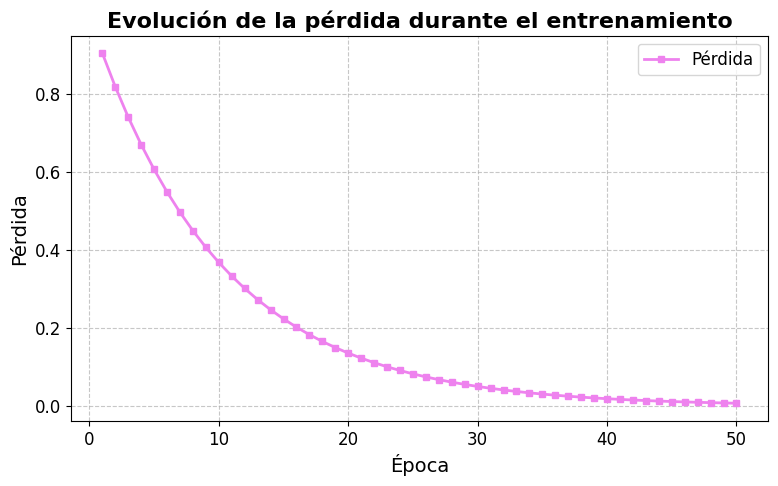

In [39]:
epocas = np.arange(1, 51)
perdida = np.exp(-0.1 * epocas)

plt.figure(figsize=(9, 5))
plt.plot(epocas, perdida, label='Pérdida', color='violet', marker='s', linewidth=2, markersize=5)

plt.title('Evolución de la pérdida durante el entrenamiento', fontsize=16, fontweight='bold')
plt.xlabel('Época', fontsize=14)
plt.ylabel('Pérdida', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(linestyle='--', alpha=0.7)

plt.show()